In [4]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import plotly.express as px

In [ ]:


df=pd.read_csv("C:/Users/Raveesha/Downloads/Hotel_Revenue_Data .csv",parse_dates=["Date"],index_col=['Date']) #Load the CSV dataset as a Dataframe
df 


,MealPeriod,CheckTotal,RevenueCenterName
Date,,,
2023-04-18,Dinner,125.0,RevenueCenter_1
2023-04-18,Dinner,37.5,RevenueCenter_1
2023-04-18,Dinner,0.0,RevenueCenter_1
2023-04-18,Dinner,0.0,RevenueCenter_1
2023-04-18,Dinner,70.0,RevenueCenter_2
...,...,...,...
2024-04-14,Lunch,40.0,RevenueCenter_5
2024-04-14,Dinner,282.0,RevenueCenter_5
2024-04-14,Lunch,166.0,RevenueCenter_5


### This dataset is a time-series dataset.
+ Anything that is observed or measured at many points in time forms a time series
+ 

In [3]:
df.index.dtype
stamp = df.index[2]
df.loc[stamp]

,MealPeriod,CheckTotal,RevenueCenterName
Date,,,
2023-04-18,Dinner,125.0,RevenueCenter_1
2023-04-18,Dinner,37.5,RevenueCenter_1
2023-04-18,Dinner,0.0,RevenueCenter_1
2023-04-18,Dinner,0.0,RevenueCenter_1
2023-04-18,Dinner,70.0,RevenueCenter_2
...,...,...,...
2023-04-18,Dinner,11400.0,RevenueCenter_8
2023-04-18,Dinner,1575.0,RevenueCenter_8
2023-04-18,Dinner,14000.0,RevenueCenter_8


In [ ]:
df.index.is_unique # Check if the index is unique


False

In [4]:
grouped_time=df.groupby(df.index.time) # Group the data by time to count how many entries occur at each distinct time
print(f"Group by time:{grouped_time.count()}")

grouped_month=df.groupby(df.index.month) # Group the data by month count how many entries occur at each distinct month
print(f"Group by month:{grouped_month.count()}")

Group by time:          MealPeriod  CheckTotal  RevenueCenterName
00:00:00      120562      120562             120562
Group by month:      MealPeriod  CheckTotal  RevenueCenterName
Date                                           
1          19976       19976              19976
2          19549       19549              19549
3          16913       16913              16913
4          11263       11263              11263
5           6649        6649               6649
6           6327        6327               6327
7           6271        6271               6271
8           6451        6451               6451
9           6850        6850               6850
10          6609        6609               6609
11          6974        6974               6974
12          6730        6730               6730


+ The time is not considered in here since it is same for all samples
+ we can either delete the time stamp keeping the date or assign a range for time looking at the meal period(Breakfast,Lunch,Dinner)

Text(0, 0.5, 'Revenue')

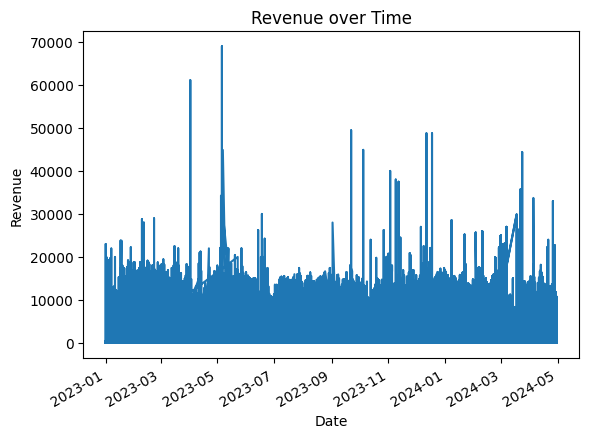

In [5]:
import matplotlib.pyplot as plt
df['CheckTotal'].plot() # Plot the Revenue column against the index(Line Plot of Revenue over Time)
plt.title("Revenue over Time")
plt.xlabel("Date")
plt.ylabel("Revenue")	

In [6]:
df["rolling_CheckTotal"]=df["CheckTotal"].rolling(window=48*30).mean()

In [7]:
df

,MealPeriod,CheckTotal,RevenueCenterName,rolling_CheckTotal
Date,,,,
2023-04-18,Dinner,125.0,RevenueCenter_1,NaN
2023-04-18,Dinner,37.5,RevenueCenter_1,NaN
2023-04-18,Dinner,0.0,RevenueCenter_1,NaN
2023-04-18,Dinner,0.0,RevenueCenter_1,NaN
2023-04-18,Dinner,70.0,RevenueCenter_2,NaN
...,...,...,...,...
2024-04-14,Lunch,40.0,RevenueCenter_5,316.275035
2024-04-14,Dinner,282.0,RevenueCenter_5,316.443090
2024-04-14,Lunch,166.0,RevenueCenter_5,316.366354


1. Consider the breakfast revenues of each day for each revenue centre for a time of the year

In [11]:
print(df['MealPeriod'].describe)

print(df.describe)
df.info


<bound method NDFrame.describe of Date
2023-04-18       Dinner
2023-04-18       Dinner
2023-04-18       Dinner
2023-04-18       Dinner
2023-04-18       Dinner
                ...    
2024-04-14        Lunch
2024-04-14       Dinner
2024-04-14        Lunch
2024-04-14       Dinner
2024-04-14    BreakFast
Name: MealPeriod, Length: 120562, dtype: object>
<bound method NDFrame.describe of            MealPeriod  CheckTotal RevenueCenterName
Date                                               
2023-04-18     Dinner       125.0   RevenueCenter_1
2023-04-18     Dinner        37.5   RevenueCenter_1
2023-04-18     Dinner         0.0   RevenueCenter_1
2023-04-18     Dinner         0.0   RevenueCenter_1
2023-04-18     Dinner        70.0   RevenueCenter_2
...               ...         ...               ...
2024-04-14      Lunch        40.0   RevenueCenter_5
2024-04-14     Dinner       282.0   RevenueCenter_5
2024-04-14      Lunch       166.0   RevenueCenter_5
2024-04-14     Dinner       180.0   Revenu

<bound method DataFrame.info of            MealPeriod  CheckTotal RevenueCenterName
Date                                               
2023-04-18     Dinner       125.0   RevenueCenter_1
2023-04-18     Dinner        37.5   RevenueCenter_1
2023-04-18     Dinner         0.0   RevenueCenter_1
2023-04-18     Dinner         0.0   RevenueCenter_1
2023-04-18     Dinner        70.0   RevenueCenter_2
...               ...         ...               ...
2024-04-14      Lunch        40.0   RevenueCenter_5
2024-04-14     Dinner       282.0   RevenueCenter_5
2024-04-14      Lunch       166.0   RevenueCenter_5
2024-04-14     Dinner       180.0   RevenueCenter_5
2024-04-14  BreakFast        40.0   RevenueCenter_5

[120562 rows x 3 columns]>

In [20]:
df_breakfast=df[df['MealPeriod']=='BreakFast']
df_breakfast_1=df[df_breakfast['RevenueCenterName']=='RevenueCenter_1']
df_breakfast_1

C:\Users\Raveesha\AppData\Local\Temp\ipykernel_5808\2652834466.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_breakfast_1=df[df_breakfast['RevenueCenterName']=='RevenueCenter_1']


IndexError: indices are out-of-bounds

### Import Dataset Processed by mysql  
* This Dataset has Organized as for a sample Date for a MealPeriod for a RevenueCentre The Total Revenue.
* THis is because the time is not recorded in dataset so it doesnt give any useful insight to the data so the samples with first 3 columns similar can be taken to one point by summing up the revenue.
* 


In [2]:

column_names=['Date','MealPeriod','RevenueCenter','Revenue']
data=pd.read_csv("C:/Users/Raveesha/Downloads/transaction_summary.csv",header=None,names=column_names,parse_dates=['Date'])

In [3]:
print(data.columns)

Index(['Date', 'MealPeriod', 'RevenueCenter', 'Revenue'], dtype='object')


In [40]:
data_breakfast1=data[(data['MealPeriod']=='BreakFast') & (data['RevenueCenter']=='RevenueCenter_1') ]
data_breakfast2=data[(data['MealPeriod']=='BreakFast') & (data['RevenueCenter']=='RevenueCenter_2') ]
data_breakfast3=data[(data['MealPeriod']=='BreakFast') & (data['RevenueCenter']=='RevenueCenter_3') ]
data_breakfast1


,Date,MealPeriod,RevenueCenter,Revenue
0,2023-01-01,BreakFast,RevenueCenter_1,1499.4
18,2023-01-02,BreakFast,RevenueCenter_1,771.0
36,2023-01-03,BreakFast,RevenueCenter_1,1302.4
56,2023-01-04,BreakFast,RevenueCenter_1,1737.0
76,2023-01-05,BreakFast,RevenueCenter_1,653.0
...,...,...,...,...
10075,2024-04-26,BreakFast,RevenueCenter_1,1005.0
10100,2024-04-27,BreakFast,RevenueCenter_1,736.0
10123,2024-04-28,BreakFast,RevenueCenter_1,863.0
10146,2024-04-29,BreakFast,RevenueCenter_1,1064.7


<Axes: >

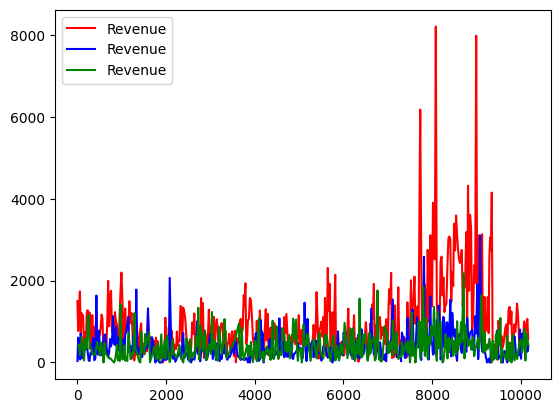

In [41]:

data_breakfast1['Revenue'].plot(color='red',legend='revenue1')
data_breakfast2['Revenue'].plot(color='blue',legend='revenue2')
data_breakfast3['Revenue'].plot(color='green',legend='revenue2')

In [63]:
data_lunch1=data[(data['MealPeriod']=='Lunch') & (data['RevenueCenter']=='RevenueCenter_1') ]
data_lunch2=data[(data['MealPeriod']=='Lunch') & (data['RevenueCenter']=='RevenueCenter_2') ]


<Axes: xlabel='Date'>

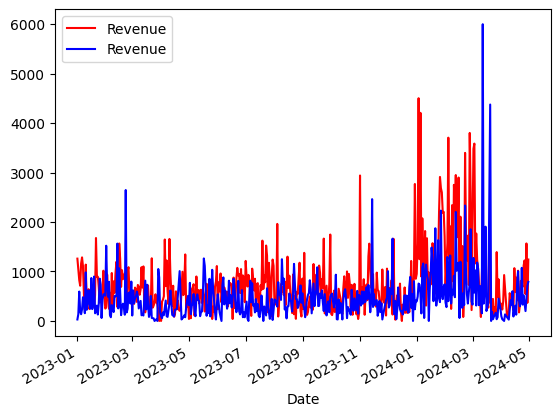

In [64]:
data_lunch1['Revenue'].plot(color='red',legend='revenue')
data_lunch2['Revenue'].plot(color='blue',legend='revenue')

In [68]:
data_dinner1=data[(data['MealPeriod']=='Dinner') & (data['RevenueCenter']=='RevenueCenter_1')]
data_dinner2=data[(data['MealPeriod']=='Dinner') & (data['RevenueCenter']=='RevenueCenter_2')]

<Axes: xlabel='Date'>

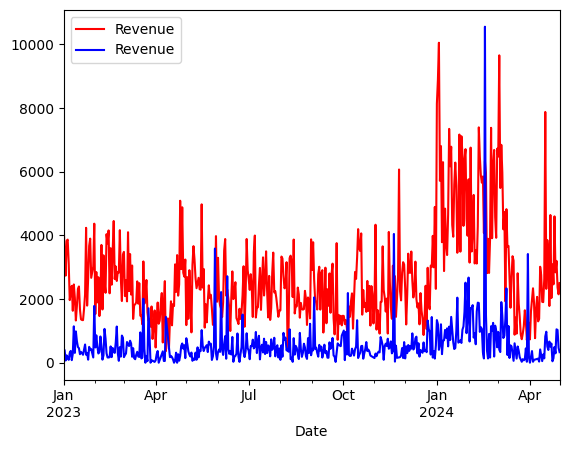

In [69]:
data_dinner1['Revenue'].plot(color='red',legend='revenue')
data_dinner2['Revenue'].plot(color='blue',legend='revenue')

# Plot yearly revenue for RevenueCentre_1


<Axes: xlabel='Date'>

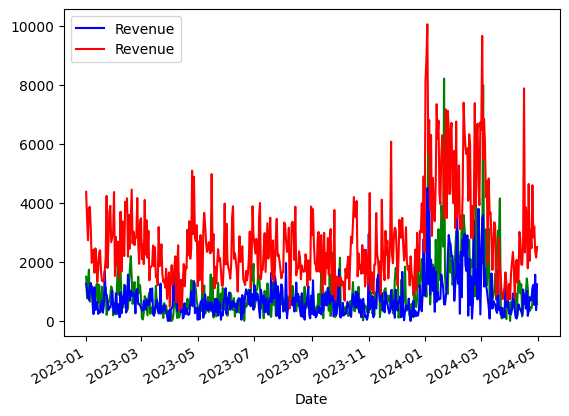

In [70]:
data_breakfast1['Revenue'].plot(color='green')
data_lunch1['Revenue'].plot(color='blue',legend='revenue')
data_dinner1['Revenue'].plot(color='red',legend='revenue')


* We can see that higher revenue is for Dinner while breakfast and Lunch have no significant difference.
* Although no significant difference between Lunch and Breakfast Breakfast shows higher revenue in most of the time.

 Monthly Average Plot

In [35]:
print(data.columns)

Index(['MealPeriod', 'RevenueCenter', 'Revenue'], dtype='object')


In [4]:
# Convert 'Date' to datetime
month_avg=data.groupby([data['Date'].dt.to_period('M'),'MealPeriod','RevenueCenter'])['Revenue'].mean().reset_index()
# Round the 'Revenue' column to one decimal place
month_avg['Revenue'] = month_avg['Revenue'].round(1)

In [5]:
month_avg

,Date,MealPeriod,RevenueCenter,Revenue
0,2023-01,BreakFast,RevenueCenter_1,839.7
1,2023-01,BreakFast,RevenueCenter_2,354.6
2,2023-01,BreakFast,RevenueCenter_3,390.5
3,2023-01,BreakFast,RevenueCenter_4,0.0
4,2023-01,BreakFast,RevenueCenter_5,16879.6
...,...,...,...,...
424,2024-04,Lunch,RevenueCenter_5,1741.5
425,2024-04,Lunch,RevenueCenter_6,493.7
426,2024-04,Lunch,RevenueCenter_7,39.7
427,2024-04,Lunch,RevenueCenter_8,5648.6


### Weekly average plots to see any weekly patterns of Revenue

In [ ]:
#For a venue centre lets calculate average Revenue
from itertools import cycle

# Define a color cycle for revenue centers
colors = cycle(['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22'])
color_map = {center: next(colors) for center in month_avg['RevenueCenter'].unique()}

# Plot using Plotly Express
fig = px.bar(
    month_avg,
    x='RevenueCenter',
    y='Revenue',
    color='RevenueCenter',
    facet_col='MealPeriod',  # Split by MealPeriod into subplots
    color_discrete_map=color_map,
    title='Average Revenue by Revenue Center and Meal Period (January 2023)'
)

# Update layout for better readability
fig.update_layout(
    xaxis_title='Revenue Center',
    yaxis_title='Average Revenue',
    legend_title='Revenue Center',
    width=1000,
    height=600,
    showlegend=False  # Hide legend since we have colors per bar
)

# Rotate x-axis labels for better readability
fig.update_xaxes(tickangle=45)

# Show the plot
fig.show()

In [10]:

# Create a line plot for each MealPeriod
meal_periods = month_avg['MealPeriod'].unique()
line_styles = cycle(['solid', 'dash', 'dot', 'dashdot'])
# Create the 'Month' column by extracting the month-year period
month_avg['Month'] = month_avg['Date'] # Convert to string for plotting
for meal in meal_periods:
    df_meal = month_avg[month_avg['MealPeriod'] == meal]
    fig = px.line(
        df_meal,
        x='Month',
        y='Revenue',
        color='RevenueCenter',
        color_discrete_map=color_map,
        title=f'Revenue by Revenue Center for {meal} (2023)'
    )
    for trace, style in zip(fig.data, line_styles):
        trace.line.dash = style
    fig.update_layout(
        xaxis_title='Month',
        yaxis_title='Revenue',
        legend_title='Revenue Center',
        width=800,
        height=500,
        template='plotly_white',
    )
    fig.update_xaxes(tickangle=45)
    fig.show()


TypeError: Type is not JSON serializable: Period

In [11]:
import pandas as pd
import plotly.express as px
from itertools import cycle

# Define column names
column_names = ['Date', 'MealPeriod', 'RevenueCenter', 'Revenue']

# Read the CSV with 'Date' as index and parse dates
data = pd.read_csv("C:/Users/Raveesha/Downloads/transaction_summary.csv", header=None, names=column_names, parse_dates=['Date'], index_col=['Date'])

# Reset index to move 'Date' back into a column
data = data.reset_index()

# Create the 'Month' column as a string (convert Period to string)
data['Month'] = data['Date'].dt.to_period('M').astype(str)

# Group by Month, MealPeriod, and RevenueCenter
month_avg = data.groupby(['Month', 'MealPeriod', 'RevenueCenter'])['Revenue'].mean().reset_index()

# Round the 'Revenue' column to one decimal place
month_avg['Revenue'] = month_avg['Revenue'].round(1)

# Get unique meal periods
meal_periods = month_avg['MealPeriod'].unique()

# Define a color cycle and line style cycle for revenue centers
colors = cycle(['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2'])
color_map = {center: next(colors) for center in month_avg['RevenueCenter'].unique()}
line_styles = cycle(['solid', 'dash', 'dot', 'dashdot'])

# Create a separate plot for each meal period
for meal in meal_periods:
    # Filter data for the current meal period
    df_meal = month_avg[month_avg['MealPeriod'] == meal]
    
    # Create line plot
    fig = px.line(
        df_meal,
        x='Month',
        y='Revenue',
        color='RevenueCenter',
        color_discrete_map=color_map,
        title=f'Revenue by Revenue Center for {meal} (2023)'
    )
    
    # Update line styles to alternate (e.g., solid, dashed)
    for trace, style in zip(fig.data, line_styles):
        trace.line.dash = style
    
    # Update layout to match the style of the original plot
    fig.update_layout(
        xaxis_title='Month',
        yaxis_title='Revenue',
        legend_title='Revenue Center',
        width=800,
        height=500,
        template='plotly_white',
    )
    
    # Rotate x-axis labels for better readability
    fig.update_xaxes(tickangle=45)
    
    # Show the plot
    fig.show()

In [ ]:
import pandas as pd
import plotly.express as px
from itertools import cycle

# Define column names
column_names = ['Date', 'MealPeriod', 'RevenueCenter', 'Revenue']

# Read the CSV with 'Date' as index and parse dates
data = pd.read_csv("C:/Users/Raveesha/Downloads/transaction_summary.csv", header=None, names=column_names, parse_dates=['Date'], index_col=['Date'])

# Reset index to move 'Date' back into a column
data = data.reset_index()

# Extract the day of the week (0 = Monday, 6 = Sunday)
data['DayOfWeek'] = data['Date'].dt.dayofweek

# Map day numbers to day names, ensuring Monday is first and Sunday is last
day_map = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
data['DayOfWeekName'] = data['DayOfWeek'].map(day_map)

# Order the days of the week correctly (Monday to Sunday)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
data['DayOfWeekName'] = pd.Categorical(data['DayOfWeekName'], categories=day_order, ordered=True)

# Group by DayOfWeekName, MealPeriod, and RevenueCenter to calculate average revenue
weekly_avg = data.groupby(['DayOfWeekName', 'MealPeriod', 'RevenueCenter'])['Revenue'].mean().reset_index()

# Round the 'Revenue' column to one decimal place
weekly_avg['Revenue'] = weekly_avg['Revenue'].round(1)

# Verify the result and check unique meal periods
print(weekly_avg.head())
print("Unique Meal Periods:", weekly_avg['MealPeriod'].unique())

# Get unique meal periods
meal_periods = weekly_avg['MealPeriod'].unique()

# Define a color cycle and line style cycle for revenue centers
colors = cycle(['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2'])
color_map = {center: next(colors) for center in weekly_avg['RevenueCenter'].unique()}
line_styles = cycle(['solid', 'dash', 'dot', 'dashdot'])

# Create a separate plot for each meal period
for meal in meal_periods:
    # Filter data for the current meal period
    df_meal = weekly_avg[weekly_avg['MealPeriod'] == meal]
    
    # Create line plot
    fig = px.line(
        df_meal,
        x='DayOfWeekName',
        y='Revenue',
        color='RevenueCenter',
        color_discrete_map=color_map,
        title=f'Average Revenue by Day of Week for {meal} (2023)'
    )
    
    # Update line styles to alternate (e.g., solid, dashed)
    for trace, style in zip(fig.data, line_styles):
        trace.line.dash = style
    
    # Update layout to match the style
    fig.update_layout(
        xaxis_title='Day of Week',
        yaxis_title='Average Revenue',
        legend_title='Revenue Center',
        width=800,
        height=500,
        template='plotly_white',
    )
    
    # Rotate x-axis labels for better readability
    fig.update_xaxes(tickangle=45)
    
    # Show the plot
    fig.show()

C:\Users\Raveesha\AppData\Local\Temp\ipykernel_18744\764255387.py:26: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



  DayOfWeekName MealPeriod    RevenueCenter  Revenue
0        Monday  BreakFast  RevenueCenter_1    875.6
1        Monday  BreakFast  RevenueCenter_2    438.5
2        Monday  BreakFast  RevenueCenter_3    387.6
3        Monday  BreakFast  RevenueCenter_4      0.0
4        Monday  BreakFast  RevenueCenter_5  17053.8
Unique Meal Periods: ['BreakFast' 'Dinner' 'Lunch']


## Setting a Strong Baseline Forecast

In [5]:
# Define column names
column_names = ['Date', 'MealPeriod', 'RevenueCenter', 'Revenue']

# Read the CSV with 'Date' as index and parse dates
dataset=pd.read_csv('C:/Users/Raveesha/Downloads/transaction_summary.csv',header=None,names=column_names,parse_dates=['Date'])
 # remove the "HH:MM:SS" from "YYYY-MM-DD HH:MM:SS"
#dataset['Date'] = pd.to_datetime(dataset['Date']).dt.date

In [6]:
dataset

,Date,MealPeriod,RevenueCenter,Revenue
0,2023-01-01,BreakFast,RevenueCenter_1,1499.4
1,2023-01-01,BreakFast,RevenueCenter_2,35.0
2,2023-01-01,BreakFast,RevenueCenter_4,0.0
3,2023-01-01,BreakFast,RevenueCenter_5,21807.0
4,2023-01-01,BreakFast,RevenueCenter_6,93.0
...,...,...,...,...
10185,2024-04-30,Dinner,RevenueCenter_4,0.0
10186,2024-04-30,Dinner,RevenueCenter_5,2979.0
10187,2024-04-30,Dinner,RevenueCenter_6,292.0
10188,2024-04-30,Dinner,RevenueCenter_8,12640.0


In [7]:
breakfast_data=dataset[dataset['MealPeriod']=='BreakFast']
breakfast_data

,Date,MealPeriod,RevenueCenter,Revenue
0,2023-01-01,BreakFast,RevenueCenter_1,1499.4
1,2023-01-01,BreakFast,RevenueCenter_2,35.0
2,2023-01-01,BreakFast,RevenueCenter_4,0.0
3,2023-01-01,BreakFast,RevenueCenter_5,21807.0
4,2023-01-01,BreakFast,RevenueCenter_6,93.0
...,...,...,...,...
10169,2024-04-30,BreakFast,RevenueCenter_4,0.0
10170,2024-04-30,BreakFast,RevenueCenter_5,12496.0
10171,2024-04-30,BreakFast,RevenueCenter_6,147.0
10172,2024-04-30,BreakFast,RevenueCenter_7,43.0


In [8]:
#RevenueCenter1 dataset
date_data=pd.DataFrame(dataset['Date'].drop_duplicates().reset_index(drop=True),columns=['Date'])
date_data


,Date
0,2023-01-01
1,2023-01-02
2,2023-01-03
3,2023-01-04
4,2023-01-05
...,...
481,2024-04-26
482,2024-04-27
483,2024-04-28
484,2024-04-29


In [9]:
# Filter breakfast_data for RevenueCenter_1 and select relevant columns
rc1_data = breakfast_data[breakfast_data['RevenueCenter'] == 'RevenueCenter_1'][['Date', 'Revenue']]

# Merge date_data with rc1_data on the Date column
date_data = date_data.merge(rc1_data, on='Date', how='left')


In [10]:
# If Revenue column exists from merge, use it; fill missing with 0
date_data['Revenue'] = date_data['Revenue'].fillna(0)
date_data

,Date,Revenue
0,2023-01-01,1499.4
1,2023-01-02,771.0
2,2023-01-03,1302.4
3,2023-01-04,1737.0
4,2023-01-05,653.0
...,...,...
481,2024-04-26,1005.0
482,2024-04-27,736.0
483,2024-04-28,863.0
484,2024-04-29,1064.7


### Train Test Validation Split

* Validation set: February 2024 (month 2, year 2024).
* Test set: March 2024 (month 3, year 2024).
* Training set: All data from January 2023 to January 2024 (excluding February and March 2024)

In [15]:
val_mask = (date_data['Date'].dt.year == 2024) & (date_data['Date'].dt.month == 3)
test_mask = (date_data['Date'].dt.year == 2024) & (date_data['Date'].dt.month == 4)
train = date_data[~(val_mask | test_mask)]
val = date_data[val_mask]
test = date_data[test_mask]

print(f"# of Training samples: {len(train)} | # of Validation samples: {len(val)} | # of Test samples: {len(test)}")
print(f"Max Date in Train: {train['Date'].max()} | Min Date in Validation: {val['Date'].min()} | Min Date in Test: {test['Date'].min()}")

# of Training samples: 425 | # of Validation samples: 31 | # of Test samples: 30
Max Date in Train: 2024-02-29 00:00:00 | Min Date in Validation: 2024-03-01 00:00:00 | Min Date in Test: 2024-04-01 00:00:00


### Training a model on the data
* Use a DateFeatures transformer to work with date data in a dataset. It processes date-related columns to create new features.

In [11]:


from sklearn.base import TransformerMixin, BaseEstimator

class DateFeatures(BaseEstimator, TransformerMixin):
    features = ['year', 'month', 'weekday', 'day', 'quarter']

    def __init__(self):
        super().__init__()

    def transform(self, df: pd.DataFrame):
        Xt = []
        for col in df.columns:
            # Validate that the column is datetime
            if not pd.api.types.is_datetime64_any_dtype(df[col]):
                raise ValueError(f"Column {col} must be a datetime type")
            for feature in self.features:
                date_feature = getattr(
                    getattr(
                        df[col], 'dt'
                    ),
                    feature
                )
                Xt.append(date_feature)

        # Concatenate and assign proper column names
        df2 = pd.concat(Xt, axis=1)
        df2.columns = [f"{col}_{feature}" for col in df.columns for feature in self.features]
        return df2

    def fit(self, df: pd.DataFrame, y=None, **fit_params):
        return self

In [8]:
from sklearn.base import TransformerMixin,BaseEstimator

class DateFeatures(BaseEstimator,TransformerMixin):
    features=['year','month','weekday','day','quater']

    def __init__(self):
        super.__init__()

    def transform(self,df:pd.DataFrame):
        Xt=[]
        for col in df.columns:
              for feature in self.features:
                 date_feature=getattr(
                     getattr(
                         df[col],'dt'),
                         feature)
                 date_feature.name = f"{col}_{feature}"
                 Xt.append(date_feature)
 
        df2 = pd.concat(Xt, axis=1)
        return df2
    def fit(self, df: pd.DataFrame, y=None, **fit_params):
        return self

ImportError: cannot import name 'ComplexWarning' from 'numpy.core.numeric' (c:\Users\Raveesha\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\core\numeric.py)

In [12]:
#apply the transformers to the date column of the DataFrame
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline,make_pipeline

# Define the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("date", make_pipeline(
            DateFeatures(),
        ), ['Date']),  # Apply DateFeatures to the 'Date' column
        ("remainder", "passthrough")  # Pass through other columns (e.g., pred_revenue)
    ])

In [13]:
from xgboost import XGBRegressor
pipeline=Pipeline([("preprocessing", preprocessor),
                   ("xgb", XGBRegressor(objective="reg:squarederror",n_estimators=100))])

In [22]:
#prepare a dataset for time series prediction
TRAINSIZE=len(train)
HORIZON=1                      #Defines the prediction horizon as 1 day (the model predicts 1 day into the future)
TARGET_COL="pred_revenue" #Specifies the target column (the variable to predict), which is "pred_revenue"


In [23]:
X_train,X_test=date_data.iloc[HORIZON:TRAINSIZE],date_data.iloc[TRAINSIZE:]
y_train = date_data.shift(periods=HORIZON).iloc[HORIZON:TRAINSIZE][TARGET_COL]
y_test = date_data.shift(periods=HORIZON).iloc[TRAINSIZE+HORIZON:][TARGET_COL]

KeyError: 'pred_revenue'

In [24]:
FEATURE_COLS = ["Date"]
pipeline.fit(X_train[FEATURE_COLS],y_train)


ValueError: not enough values to unpack (expected 3, got 2)

In [ ]:


# Define the maximum horizon for prediction
MAX_HORIZON = 90

# Create a series of future dates starting from the day after the last date in the dataset
start_date = date_data['Date'].max() + pd.Timedelta(days=1)  # Next day after last date
X_test_horizon = pd.Series(
    pd.date_range(
        start=start_date,
        periods=MAX_HORIZON,  # Only predict for 90 days
        name="date"
    )
).reset_index(drop=True)

In [ ]:
# The predict() method of the pipeline applied to X_test gives us the forecast
forecasted = pd.concat(
    [
        pd.Series(pipeline.predict(X_test_horizon[FEATURE_COLS]), name=TARGET_COL),
        pd.Series(X_test_horizon['date'], name='date')
    ],
    axis=1
)
forecasted.columns = [TARGET_COL, 'date']

In [ ]:
# We can do the same for the actual cases
actual = pd.concat(
    [
        pd.Series(date_data[TARGET_COL], name=TARGET_COL),
        pd.Series(date_data['Date'], name='date')
    ],
    axis=1
)
actual.columns = [TARGET_COL, 'date']

In [ ]:
import matplotlib.pyplot as plt

# Now, we can contrast the forecast with the actual values, y_test, in a plot
fig, ax = plt.subplots(figsize=(12, 6))
forecasted.set_index('date').plot(linestyle='--', ax=ax)
actual.set_index('date').plot(linestyle='-', ax=ax)
plt.legend(["forecast", "actual"])
plt.title("Forecast vs Actual Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()